In [123]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_frame = pd.read_csv('/content/riceClassification.csv')
data_frame.head() # First 5 rows

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [124]:
data_frame.dropna(inplace = True) # remove the rows that contain missing values
data_frame.drop(['id'], axis = 1, inplace = True) # axis - 0 (rows) || axis - 1 (columns)
# Removes the column name id
print(data_frame.shape)


(18185, 11)


In [125]:
data_frame.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [126]:
print(data_frame["Class"].value_counts())
# this counts how many times each value appears in the "Class" column.

Class
1    9985
0    8200
Name: count, dtype: int64


In [127]:
original_dataframe = data_frame.copy()

for column in data_frame.columns:
  data_frame[column] = data_frame[column]/data_frame[column].abs().max()
data_frame.head()

# First, make a copy of the original dataframe.
# Then, for each column, divide all values by that column's maximum absolute value to normalize the data.
# Finally, display the first five rows of the normalized dataframe

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [128]:
X = np.array(data_frame.iloc[:, :-1])
Y = np.array(data_frame.iloc[:, -1])
# Separate the dataset into input features (X) and output labels (Y).
# X contains all columns except the last column, which are used as inputs for the model.
# Y contains only the last column, which is the target value the model will learn to predict.
# The selected data is converted into NumPy arrays for easier processing in machine learning.

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3)

In [130]:
X_test, X_val,y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5)


In [131]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [132]:
class dataset(Dataset):
  def __init__(self, X, Y):
    self.X = torch.tensor(X, dtype = torch.float32).to(device) # Convert X to tensor
    self.Y = torch.tensor(Y, dtype = torch.float32).to(device) # Convert Y to tensor
  def __len__(self):
    return len(self.X)
  def __getitem__(self, index):
    return self.X[index], self.Y[index]

# "When a dataset object is created, receive X and Y."

In [133]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [134]:
train_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = 32, shuffle = True)
testing_loader = DataLoader(testing_data, batch_size = 32, shuffle = True)

In [135]:
for x, y in train_dataloader:
  print(x)
  print("=====")
  print(y)
  break


tensor([[0.8376, 0.8654, 0.8454, 0.9288, 0.7976, 0.9152, 0.8904, 0.7422, 0.8339,
         0.5807],
        [0.5977, 0.8175, 0.6347, 0.9690, 0.5635, 0.7731, 0.5562, 0.6582, 0.7566,
         0.7307],
        [0.6334, 0.9186, 0.6000, 0.9886, 0.6037, 0.7959, 0.5240, 0.7198, 0.6704,
         0.8687],
        [0.7203, 0.7946, 0.7847, 0.9263, 0.6800, 0.8487, 0.6757, 0.6735, 0.8708,
         0.5745],
        [0.8779, 0.8726, 0.8748, 0.9228, 0.8374, 0.9369, 0.6763, 0.7535, 0.8480,
         0.5659],
        [0.8163, 0.8312, 0.8521, 0.9174, 0.7724, 0.9035, 0.7418, 0.7199, 0.8638,
         0.5535],
        [0.5327, 0.8043, 0.5812, 0.9780, 0.5065, 0.7299, 0.5293, 0.6432, 0.7062,
         0.7851],
        [0.8874, 0.8741, 0.8856, 0.9203, 0.8489, 0.9420, 0.6567, 0.7717, 0.8171,
         0.5600],
        [0.5564, 0.7885, 0.6175, 0.9678, 0.5274, 0.7459, 0.8995, 0.6371, 0.7518,
         0.7245],
        [0.8381, 0.8463, 0.8600, 0.9196, 0.7983, 0.9155, 0.8705, 0.7312, 0.8597,
         0.5583],
        [0

In [136]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel, self).__init__()

    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS, 1)
    self.sigmoid = nn.Sigmoid()


  def forward(self, x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

model = MyModel().to(device)


In [137]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [138]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = 1e-3)

In [139]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10

for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in train_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = criterion(prediction, labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()

    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data

      prediction = model(inputs).squeeze(1)

      batch_loss = criterion(prediction, labels)

      total_loss_val += batch_loss.item()

      acc = ((prediction).round() == labels).sum().item()
      total_acc_val += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
  total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100 , 4))

  print(f'''Epoch no. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__() * 100, 4)}
        Validation Loss:  {round(total_loss_val/1000,4)} Validation Accuracy: {round(total_acc_val/validation_data.__len__() * 100 , 4)}''')
  print("="*25)










Epoch no. 1 Train Loss: 0.2395 Train Accuracy 80.7919
        Validation Loss:  0.0392 Validation Accuracy: 98.6437
Epoch no. 2 Train Loss: 0.118 Train Accuracy 97.9574
        Validation Loss:  0.0155 Validation Accuracy: 98.3138
Epoch no. 3 Train Loss: 0.0534 Train Accuracy 98.4288
        Validation Loss:  0.0086 Validation Accuracy: 98.1672
Epoch no. 4 Train Loss: 0.0344 Train Accuracy 98.5073
        Validation Loss:  0.0062 Validation Accuracy: 98.5704
Epoch no. 5 Train Loss: 0.0267 Train Accuracy 98.6095
        Validation Loss:  0.0052 Validation Accuracy: 98.5704
Epoch no. 6 Train Loss: 0.0228 Train Accuracy 98.5781
        Validation Loss:  0.0046 Validation Accuracy: 98.6804
Epoch no. 7 Train Loss: 0.0207 Train Accuracy 98.5781
        Validation Loss:  0.0043 Validation Accuracy: 98.6804
Epoch no. 8 Train Loss: 0.0194 Train Accuracy 98.6095
        Validation Loss:  0.004 Validation Accuracy: 98.6804
Epoch no. 9 Train Loss: 0.0185 Train Accuracy 98.6016
        Validation L

In [140]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test  = 0
  for data in testing_loader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion(prediction, labels).item()
    total_loss_test += batch_loss_test

    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print("Accuracy: ", round(total_acc_test/testing_data.__len__() * 100, 4))



Accuracy:  98.827


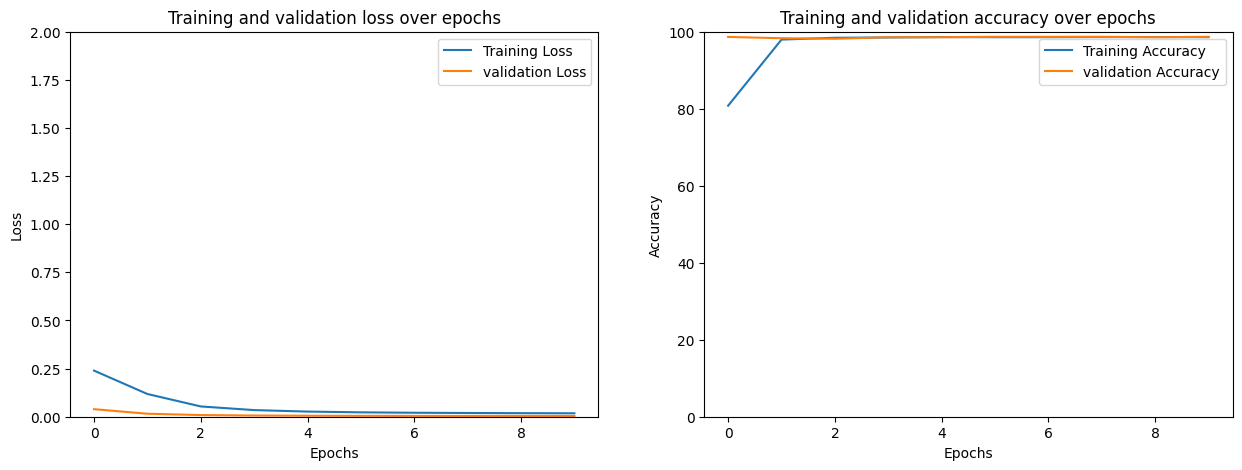

In [142]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'validation Loss')
axs[0].set_title("Training and validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,2])
axs[0].legend()


axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'validation Accuracy')
axs[1].set_title("Training and validation accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()


In [151]:
area = 2353/original_dataframe['Area'].abs().max()

MajorAxisLength = 81/original_dataframe['MajorAxisLength'].abs().max()

MinorAxisLength = 42/original_dataframe['MinorAxisLength'].abs().max()

Eccentricity = 32/original_dataframe['Eccentricity'].abs().max()

ConvexArea  = 12/original_dataframe['ConvexArea'].abs().max()

EquivDiameter = 33/original_dataframe['EquivDiameter'].abs().max()

Extent  = 98/original_dataframe['Extent'].abs().max()

Perimeter  = 927/original_dataframe['Perimeter'].abs().max()

Roundness = 677/original_dataframe['Roundness'].abs().max()

AspectRation = 27/original_dataframe['AspectRation'].abs().max()


my_prediction = model(torch.tensor([area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation], dtype = torch.float32).to(device))

In [145]:
original_dataframe.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [154]:
round(my_prediction.item())

0